In [2]:
from langgraph.graph import StateGraph,START,MessagesState
from langchain_groq import ChatGroq
from dotenv import load_dotenv
from langgraph.checkpoint.memory import InMemorySaver
from langchain.messages import RemoveMessage


In [3]:
load_dotenv()

True

In [4]:
llm = ChatGroq(model="llama-3.3-70b-versatile")

In [5]:
def chat(state: MessagesState):
    response = llm.invoke(state["messages"])
    return {"messages": [response]}

def delete_old_messages(state: MessagesState):
    msgs = state["messages"]

    # if more than 10 messages, delete the earliest 6
    if len(msgs) > 10:
        to_remove = msgs[:6]
        return {"messages": [RemoveMessage(id=m.id) for m in to_remove]}

    return {}


In [6]:
builder = StateGraph(MessagesState)
builder.add_node("chat", chat)
builder.add_node("cleanup", delete_old_messages)

In [7]:
builder.add_edge(START, "chat")
builder.add_edge("chat", "cleanup")   # run deletion after each response
builder.add_edge("cleanup", "__end__")

In [8]:
graph = builder.compile(checkpointer=InMemorySaver())

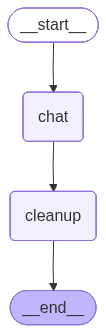

In [9]:
graph

In [10]:
config = {"configurable": {"thread_id": "t1"}}

In [11]:
# Run multiple turns
graph.invoke({"messages": [{"role": "user", "content": "Hi, I'm Pranjal"}]}, config)
graph.invoke({"messages": [{"role": "user", "content": "Tell me about LangGraph"}]}, config)
graph.invoke({"messages": [{"role": "user", "content": "Now explain checkpointers"}]}, config)
graph.invoke({"messages": [{"role": "user", "content": "What is Langchain"}]}, config)
graph.invoke({"messages": [{"role": "user", "content": "What is Quantum Mechanics"}]}, config)
graph.invoke({"messages": [{"role": "user", "content": "What is Gen AI"}]}, config)
graph.invoke({"messages": [{"role": "user", "content": "What is my name"}]}, config)

{'messages': [HumanMessage(content='What is Langchain', additional_kwargs={}, response_metadata={}, id='3e4c841f-5f8d-4901-9677-8b5dbd1bb69d'),
  AIMessage(content="LangChain is an open-source framework designed to simplify the development and deployment of large language models (LLMs) like LangGraph. It provides a set of tools and APIs that enable developers to build, train, and deploy LLMs with ease.\n\n**Key Features of LangChain:**\n\n1. **Modular Architecture**: LangChain is built using a modular architecture, allowing developers to easily swap out different components, such as models, optimizers, and datasets.\n2. **Pre-built Components**: LangChain provides pre-built components for common LLM tasks, such as text classification, sentiment analysis, and language translation.\n3. **Simple API**: LangChain offers a simple and intuitive API that makes it easy to interact with LLMs, including loading models, making predictions, and fine-tuning models.\n4. **Multi-Model Support**: Lang

In [12]:
snap = graph.get_state(config)
print("Stored messages after cleanup:", len(snap.values["messages"]))

Stored messages after cleanup: 8
